In [154]:
from pprint import pprint
import numpy as np
import pandas as pd
from scipy.stats import norm


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Sources: <br>
* SILVERMAN, Density Estimation for Statistics and Data Analysis <br>
* WAND, Kernel Smoothing <br>
* WASSERMAN, All of Nonparametric Statistics

# Studies

In [155]:
import numpy as np

def histogram(
    x: np.ndarray, 
    binwidth: float
) -> list:
    n = len(x)
    # Align the start to the floor of the minimum value
    x_min = np.floor(x.min())
    x_max = np.ceil(x.max())
    
    # Create the edges of the bins
    # We use arange to ensure each step is exactly 'binwidth'
    grid = np.arange(x_min, x_max + binwidth, binwidth)
    
    hist_values = []
    
    # Iterate through the grid to create adjacent bins
    for i in range(len(grid) - 1):
        bin_start = grid[i]
        bin_end = grid[i+1]
        
        # Count points in the current bin [start, end)
        count = np.sum((x >= bin_start) & (x < bin_end))
        
        # Calculate density: f_hat = count / (n * h)
        f_hat = count / (n * binwidth)
        
        # Store as (bin_range_tuple, density)
        hist_values.append(f_hat)

    return grid, hist_values

In [3]:
grid, hist = histogram(
    x = np.array([1.5, 1.7, 1.8, 1.9, 3, 4.9, 5.1]),
    binwidth = 0.5
    )

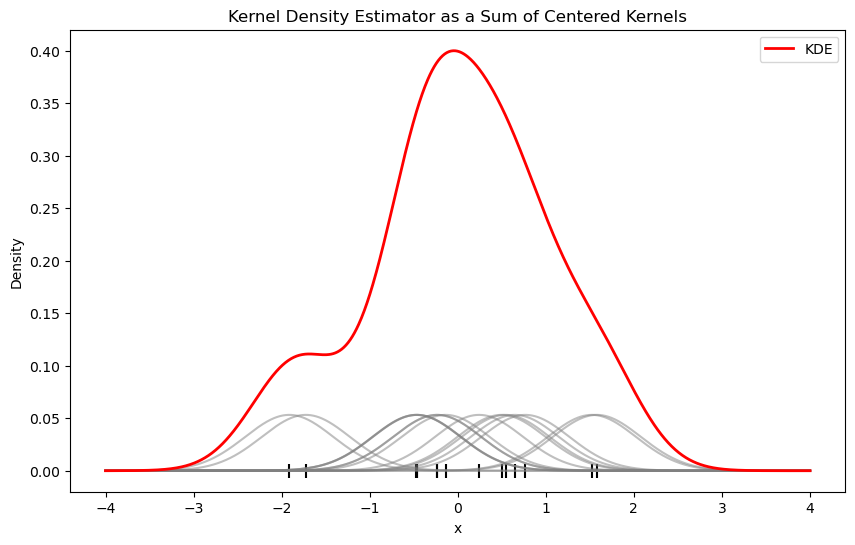

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Sample data
# ---------------------------
np.random.seed(42)
X = np.random.normal(loc=0, scale=1, size=15)
n = len(X)

# ---------------------------
# Parameters
# ---------------------------
h = 0.5  # bandwidth
x_grid = np.linspace(-4, 4, 1000)

# ---------------------------
# Gaussian kernel function
# ---------------------------
def gaussian_kernel(u):
    return norm.pdf(u)  # standard normal kernel

# ---------------------------
# Compute individual kernels
# ---------------------------
kernels = []

for xi in X:
    k = (1 / h) * gaussian_kernel((x_grid - xi) / h)
    kernels.append(k)

kernels = np.array(kernels)

# ---------------------------
# Compute KDE as average
# ---------------------------
kde = (1 / n) * np.sum(kernels, axis=0)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Plot individual centered kernels
for i in range(n):
    plt.plot(x_grid, kernels[i] / n, color='gray', alpha=0.5)

# Plot final KDE
plt.plot(x_grid, kde, color='red', linewidth=2, label='KDE')

# Rug plot
plt.scatter(X, np.zeros_like(X), marker='|', color='black', s=100)

plt.title("Kernel Density Estimator as a Sum of Centered Kernels")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

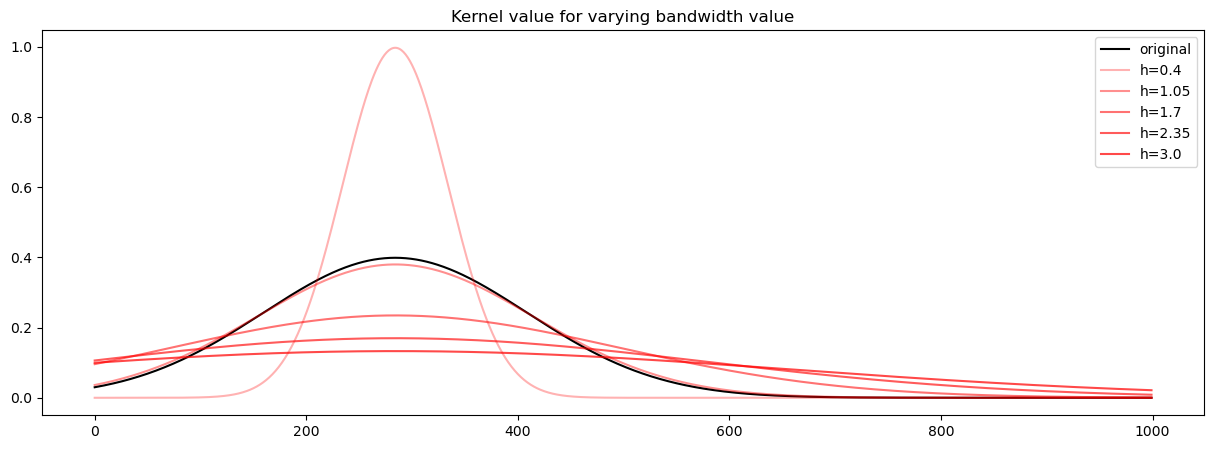

In [5]:
plt.figure(figsize=(15,5))

plt.plot(
    norm.pdf(
        (x_grid - xi)
        )
    , label="original"
    , c="black"
    )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )
#     , label="weighed"
#     )

# plt.plot(
#     norm.pdf(
#         (x_grid - xi)/h
#         )/h
#     , label="weighed_2"
#     )

alpha0 = 0.3
steps = 5
for h in np.linspace(0.4, 3, steps):
    plt.plot(
        norm.pdf(
            (x_grid - xi)/h
            )/h
        , label=f"h={h:.3}"
        , color="red"
        , alpha=alpha0
        )
    
    alpha0 += (1-alpha0)/steps

plt.title("Kernel value for varying bandwidth value")
plt.legend()
plt.show()

# Development

In [159]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut, KFold
from sklearn.neighbors import KernelDensity
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from typing import Union, Optional, Iterable, Any, List
from scipy import stats
import warnings
from scipy.stats import norm, t

## Single observation

In [156]:
AVAILABLE_KERNELS = ["gaussian", "epanechnikov", "t-student"]

In [157]:
def get_rot_bandwidth_ck():
    # Kernel-dependent constants for bandwidth selection
    CK_GAUSSIAN_SILVERMAN = 1.06
    CK_GAUSSIAN_SILVERMAN_ADJUSTED = 0.9
    CK_EPANECHNIKOV_SILVERMAN = 2.34

    ROT_BANDWIDTH_CK = {
        "gaussian": {
            "silverman":          CK_GAUSSIAN_SILVERMAN,
            "silverman_adjusted": CK_GAUSSIAN_SILVERMAN_ADJUSTED,

        },
        "epanechnikov": {
            "silverman":          CK_EPANECHNIKOV_SILVERMAN,
            # "silverman_adjusted": CK_GAUSSIAN_SILVERMAN_ADJUSTED * CK_EPANECHNIKOV_SILVERMAN / CK_GAUSSIAN_SILVERMAN # scaled to preserve Silverman/Gaussian ratio
        },
    }
    return ROT_BANDWIDTH_CK

# t_kernel_rot = {
#     '3': 1.192,
#     '4': 1.141,
#     '5': 1.116
#     }

In [285]:
def _gaussian_kernel(u):
    """
    Gaussian kernel.
    """
    print("Using gaussian kernel")
    return norm.pdf(u)

def _t_student_kernel(u, df):
    """
    Student-t kernel.

    Parameters
    ----------
    df : int
        Degrees of freedom.
    """
    print(f"Using t-kernel with df={df}")
    return t.pdf(u, df=df)

def _epanechnikov_kernel(u):
    """
    Epanechnikov kernel.
    """
    print("Using epanechnikov kernel")
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1)

def _pilot_density(
        X, 
        h,
        kernel: str = "gaussian",
        **kwargs
        ):
    """
    Compute pilot density estimate at sample points.
    """
    print(f"Pilot density of {kernel}")

    # Convert to NumPy array
    X = np.asarray(X, dtype=float)

    # Pairwise standardized distances:
    # u_ij = (X_i - X_j) / h
    u = (X[:, None] - X[None, :]) / h

    # Gaussian kernel evaluation
    if kernel=="t-student":
        pdf = _t_student_kernel(u, **kwargs)
    else:
        pdf = _gaussian_kernel(u)

    # KDE formula evaluated at sample points
    f_pilot = np.mean(pdf / h, axis=1)

    return f_pilot

def _optimize_sklearn(X, bandwidths, cv, kernel):
    """Internal helper for standard Scikit-Learn kernels."""
    print("Using sklearn for CV")
    grid = GridSearchCV(
        estimator=KernelDensity(kernel=kernel),
        param_grid={"bandwidth": bandwidths},
        cv=cv,
        n_jobs=-1
    )
    grid.fit(X.reshape(-1, 1))
    return grid.best_params_["bandwidth"]

def _optimize_t_student(X, bandwidths, cv, df):
    """Internal helper for manual Student-t LCV."""
    print(f"Using t kernel for CV with df={df}")

    max_log_lik = -np.inf
    best_h = bandwidths[0]
    
    # If cv is LeaveOneOut, cv.split(X) works natively. 
    # If int/KFold, it also works.
    for h in bandwidths:
        fold_log_liks = []
        for train_idx, val_idx in cv.split(X):
            train, val = X[train_idx], X[val_idx]
            
            # Distance matrix (n_val, n_train)
            u = (val[:, None] - train[None, :]) / h
            # Student-t Density: f_hat = (1/nh) * sum( K(u) )
            densities = stats.t.pdf(u, df=df) / h
            f_hat = np.mean(densities, axis=1)
            
            # Log-likelihood (with numerical floor)
            fold_log_liks.append(np.sum(np.log(np.maximum(f_hat, 1e-300))))
            
        avg_log_lik = np.mean(fold_log_liks)
        if avg_log_lik > max_log_lik:
            max_log_lik = avg_log_lik
            best_h = h
    return best_h

In [274]:
class BandwidthSelector:
    def __init__(
            self,
            X: pd.Series,
            kernel: str = "gaussian",
            **kwargs
        ):
        self.X = X
        self.kernel = kernel
        self.n = X.shape[0]
        self.kwargs = kwargs

    def rot_constants(self) -> List[tuple]:
        rot_elements = get_rot_bandwidth_ck()
        combinations = [
                        (kernel, rule, value) 
                        for kernel, rules in rot_elements.items() 
                        for rule, value in rules.items()
        ]
        
        return combinations

    def rot(
            self,
            rule:         str = "silverman",
            sigma_robust: bool = False,
            return_list:  bool = True,
            kernel:       str = None
        ) -> Union[float, np.array]:
        """
            Compute the Rule of Thumb (ROT) bandwidth for Kernel Density Estimation.

            This method provides a closed-form estimate of the optimal bandwidth (h) 
            based on the assumption that the underlying distribution is approximately 
            normal. It is significantly faster than Cross-Validation but may 
            over-smooth multimodal distributions.

            Parameters
            ----------
            kernel_rule : list of str, default=["gaussian", "silverman"]. See get_rot_bandwidth_ck()
            for available constants.
                A pair defining the kernel type and the specific rule:
                - Index 0: Kernel name (e.g., "gaussian", "epanechnikov").
                - Index 1: Rule variant (e.g., "silverman").
            sigma_robust : bool, default=False
                If True, uses a robust estimator of scale: min(std, IQR/1.349).
                This prevents outliers from artificially inflating the bandwidth 
                (over-smoothing).
            return_list : bool, default=True
                - If True, returns a NumPy array of length 'n' where every entry is 
                the calculated bandwidth.
                - If False, returns a single float value for the global bandwidth.

            Returns
            -------
            bandwidth : float or np.ndarray
                The calculated bandwidth(s).

            Notes
            -----
            The bandwidth is calculated using the formula:
                h = C_k * σ * n^(-1/5)
            
            where:
            - C_k is a kernel-specific constant (e.g., 1.06 for Silverman's Gaussian).
            - σ is the standard deviation (or robust alternative).
            - n is the sample size.

            References
            ----------
            Silverman, B. W. (1986). Density Estimation for Statistics and Data Analysis.
            Scott, D. W. (1992). Multivariate Density Estimation.
        """
        if kernel is None:
            kernel = self.kernel
        c_k = get_rot_bandwidth_ck()[kernel][rule]

        standard_deviation = np.std(self.X, axis=0)
        if sigma_robust:
            iqr_x = np.subtract(*np.percentile(self.X, [75, 25])) / 1.349
            standard_deviation = np.min([standard_deviation, iqr_x]) if iqr_x > 0 else standard_deviation

        bandwidth = c_k * standard_deviation * self.n **(-1/5)

        print("Bandwidth:", kernel, bandwidth)

        if return_list:
            bandwidth = np.full(self.n, bandwidth)

        return bandwidth
    
    def adaptive_bandwidth(
            self,
            h: Union[str,float] = "silverman",
            alpha=0.5
        ) -> np.array:
        """
        Compute adaptive local bandwidths using the Abramson (1982) variable kernel method.

        This function implements the "square-root law" for bandwidth adaptation. It 
        scales the global bandwidth 'h' based on a pilot density estimate, allowing 
        the kernel to expand in sparse regions (tails) and contract in dense regions 
        (peaks).

        Parameters
        ----------
        X : ndarray of shape (n_samples,)
            The data points at which to evaluate the pilot density and compute bandwidths.
        h : float
            The global (initial) bandwidth. Usually determined by a rule of thumb 
            (e.g., Silverman's or Scott's rule).
        alpha : float, default=0.5
            The sensitivity parameter. 
            - alpha = 0.5: Abramson’s optimal value, which reduces the bias of the 
                KDE from O(h²) to O(h⁴).
            - alpha = 0: Results in a fixed bandwidth h.
            - 0 < alpha < 1: Varying degrees of local adaptation.

        Returns
        -------
        bandwidths : ndarray of shape (n_samples,)
            The local bandwidth values λ(X_i) * h for each point in X.

        Notes
        -----
        The adaptive bandwidth is calculated as:
            h_i = h * (f_pilot(X_i) / g)^(-alpha)

        where 'g' is the geometric mean of the pilot density f_pilot(X):
            log(g) = (1/n) * Σ log(f_pilot(X_i))

        This geometric mean normalization ensures that the product of the local 
        bandwidths remains proportional to the global bandwidth h, maintaining 
        the overall smoothing scale.

        References
        ----------
        Abramson, I. S. (1982). On bandwidth variation in kernel estimates-a 
        square root law. Annals of Statistics, 10(4), 1217-1223.
        """

        if isinstance(h, str):
            h = self.rot(kernel="gaussian", rule="silverman", return_list=False)

        f_pilot = _pilot_density(self.X, h=h, kernel=self.kernel, **self.kwargs)

        # Numerical safety
        eps = np.finfo(float).eps
        f_pilot = np.maximum(f_pilot, eps)

        g = np.exp(np.mean(np.log(f_pilot)))

        bandwidths = h * (f_pilot / g) ** (-alpha)

        print("Adaptive:", h)

        return bandwidths
        
    def cross_validate_bandwidth(
            self,
            bandwidths_grid: Optional[Iterable[float]] = None,
            cv: Union[int, str] = 5,
            # kernel: str = "gaussian",
            return_list: bool = True,
            **kernel_kwargs: Any
        ) -> Union[float, np.array]:
        """
        Select optimal KDE bandwidth via Likelihood Cross-Validation (LCV).

        Finds the global scaling factor (h) that maximizes the log-likelihood of 
        out-of-sample observations. This data-driven approach automates the 
        bias-variance tradeoff by optimizing the model's predictive density.

        Parameters
        ----------
        bandwidths_grid : array-like, optional
            Candidate bandwidth values to evaluate. If None, a logarithmic grid 
            is automatically constructed, centered around Silverman's Rule of 
            Thumb (ROT) and scaled by the data's robust volatility.
        cv : int or "LOO", default=5
            The cross-validation strategy:
            - int: Number of folds for K-Fold CV (Recommended for large n).
            - "LOO": Leave-One-Out CV (Classic approach, high computational cost).
        kernel : str, default="gaussian"
            Kernel function for density estimation. Supports Scikit-Learn kernels 
            (gaussian, epanechnikov, etc.) and custom "t-student" implementation.
        return_list : bool, default=True
            - If True: Returns an ndarray of length self.n filled with h_opt.
            - If False: Returns h_opt as a single float.
        **kernel_kwargs : Any
            Additional parameters passed to custom kernels. 
            Example: df=3 for 't-student'.

        Returns
        -------
        bandwidth : float or np.ndarray
            The optimal bandwidth(s) that maximize the cross-validated 
            log-likelihood.

        Notes
        -----
        Likelihood CV is asymptotically equivalent to minimizing the 
        Kullback-Leibler divergence between the estimated and true densities. 
        Unlike Least-Squares CV, LCV is particularly effective for heavy-tailed 
        distributions, though it can be sensitive to extreme outliers.

        Warnings
        --------
        Issues a UserWarning if the selected bandwidth lies on the boundary of 
        the provided or generated grid, suggesting the search space is insufficient.
        """

        print("CV:", self.kernel, cv)

        # 1. Input Validation and Preparation
        X = np.asarray(self.X, dtype=float).flatten()
        if X.size < 2:
            raise ValueError("Bandwidth estimation requires at least two data points.")
        
        # 2. Automated Grid Generation (Data-Dependent)
        if bandwidths_grid is None:
            std_x = np.std(X, ddof=1)
            iqr_x = np.subtract(*np.percentile(X, [75, 25])) / 1.349
            sigma_robust = np.min([std_x, iqr_x]) if iqr_x > 0 else std_x
            h_rot = 0.9 * sigma_robust * (X.size ** -0.2)
            bandwidths_grid = np.logspace(np.log10(h_rot/10), np.log10(h_rot*10), 50)

        # 3. CV Strategy Dispatch
        cv_strategy = LeaveOneOut() if cv == "LOO" else KFold(n_splits=cv, shuffle=True)

        # 4. Optimization Path Dispatch
        print("Used kernel in CV:", self.kernel)
        if self.kernel == "t-student":
            bandwidth = _optimize_t_student(X, bandwidths_grid, cv_strategy, self.kwargs.get('df'))
        else:
            bandwidth = _optimize_sklearn(X, bandwidths_grid, cv_strategy, self.kernel)

        # 5. Boundary Warning
        if np.isclose(bandwidth, np.min(bandwidths_grid)) or np.isclose(bandwidth, np.max(bandwidths_grid)):
            
            warnings.warn(
                f"Optimal bandwidth ({bandwidth:.4f}) is at the boundary of the grid for kernel '{self.kernel}'.", 
                UserWarning
            )

        if return_list:
            bandwidth = np.full(self.n, bandwidth)
        return bandwidth

### Test

In [172]:
X_single = pd.Series(np.random.standard_t(size=5001, df=2), name="date_t")

bw_single = BandwidthSelector(X_single,kernel="gaussian")

In [126]:
bw_single.rot()

array([0.46267784, 0.46267784, 0.46267784, ..., 0.46267784, 0.46267784,
       0.46267784], shape=(5001,))

In [127]:
bw_single.rot(rule="silverman_adjusted", sigma_robust=True)

array([0.1954249, 0.1954249, 0.1954249, ..., 0.1954249, 0.1954249,
       0.1954249], shape=(5001,))

In [128]:
bw_single.adaptive_bandwidth(
                    h = "silverman")

array([0.93062148, 0.40630874, 0.40703889, ..., 1.71840464, 0.37036172,
       0.84421617], shape=(5001,))

In [129]:
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv=10
)

array([0.76351335, 0.76351335, 0.76351335, ..., 0.76351335, 0.76351335,
       0.76351335], shape=(5001,))

In [ ]:
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv="LOO"
)

array([1.90285276, 1.90285276, 1.90285276, ..., 1.90285276, 1.90285276,
       1.90285276], shape=(5001,))

In [ ]:
bw_single.cross_validate_bandwidth(
    kernel="t-student",
    df=3,
    cv=5
)

array([0.4230035, 0.4230035, 0.4230035, ..., 0.4230035, 0.4230035,
       0.4230035], shape=(5001,))

### Execution time for LOO vs Kfold

In [ ]:
%%timeit
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv="LOO"
)

35.7 s ± 5.81 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
bw_single.cross_validate_bandwidth(
    kernel="gaussian",
    cv=5
)

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_3595/554080958.py:224: UserWarning: Optimal bandwidth (2.0904) is at the boundary of the grid for kernel 'gaussian'.
  warnings.warn(


2.49 s ± 13.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## For dataframe

In [ ]:
def df_bandwidth_selector(
        X: pd.DataFrame,
        kernel: str = "gaussian",
        method: str = "rot",
        # return_list: bool = True,
        **kwargs
    ) -> pd.DataFrame:
 
   
    results = {}
        
    # 1. Prepare Init Parameters
    # We pull 'df' out of kwargs if it exists to pass it to the constructor
    init_params = {'kernel': kernel}
    if kernel == "t-student" and "df" in kwargs:
        init_params["df"] = kwargs.pop("df") 
    
    # 2. Remaining kwargs are specific to the method (e.g., alpha, cv, rule)
    method_params = kwargs

    for col_name in X.columns:
        # Drop NaNs to perform calculation
        clean_col = X[col_name].dropna()
        
        if clean_col.empty:
            results[col_name] = np.full(len(X), np.nan)
            continue

        # Initialize the selector with kernel and potentially df
        selector = BandwidthSelector(clean_col, **init_params)
        
        # Get the specific method (rot, adaptive_bandwidth, etc.)
        calc_func = getattr(selector, method)
        
        # Execute the calculation
        res = calc_func(**method_params)
        
        # Map results back to the original index to preserve NaN positions
        if np.isscalar(res):
            results[col_name] = np.full(len(X), res)
        else:
            full_series = pd.Series(np.nan, index=X.index)
            full_series.loc[clean_col.index] = res
            results[col_name] = full_series.values
                
    return pd.DataFrame(results, index=X.index)

In [233]:
n_cols = 10
X = pd.DataFrame(np.random.standard_t(size=[5001, n_cols], df=2), columns=[f"date_{t}" for t in range(n_cols)])
bw_from_df = BandwidthSelector(X.iloc[:,0])

df_bandwidth_selector(X, kernel="epanechnikov", method="rot", rule="silverman")

,date_0,date_1,date_2,date_3,date_4,date_5,date_6,date_7,date_8,date_9
0,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
1,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
2,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
3,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
4,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
...,...,...,...,...,...,...,...,...,...,...
4996,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
4997,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
4998,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849
4999,2.583207,1.382488,1.194865,1.268867,1.257296,1.330224,1.117517,1.429285,1.068047,1.08849


In [234]:
df_bandwidth_selector(X, kernel="t-student", df=2, method="adaptive_bandwidth")

,date_0,date_1,date_2,date_3,date_4,date_5,date_6,date_7,date_8,date_9
0,0.947250,0.479282,0.434784,0.448871,0.427827,0.481138,0.892565,0.525432,0.397030,0.355217
1,3.233480,0.469478,0.695364,0.431071,0.763655,0.475729,0.367494,0.536801,0.377259,0.441699
2,1.097822,0.460063,4.131892,0.599309,0.504601,0.546138,0.830906,0.490185,0.715993,0.403591
3,0.965958,0.909834,0.529563,0.507094,2.742255,0.463041,0.363718,0.567774,0.360128,0.444583
4,0.974511,0.492547,0.393372,0.521006,0.414187,0.479593,0.589515,0.476727,0.341626,0.764353
...,...,...,...,...,...,...,...,...,...,...
4996,0.982641,0.470548,0.516597,0.509991,0.486207,0.483143,0.466658,0.581075,0.744328,0.422646
4997,0.961960,0.515649,0.418961,0.509985,1.587399,0.457348,0.369511,0.514714,0.342122,0.451344
4998,1.152765,0.573942,0.589119,0.591401,0.560286,0.480568,0.397318,0.655686,0.343963,0.363839
4999,1.039103,0.459755,0.390393,0.423339,0.912232,0.449527,0.567614,0.512825,0.481274,0.482425


## Cleaned KDE class

In [300]:
class KernelDensityEstimation:
    """
    Description
    ---------
    Kernel Density Estimation for (functional) data.

    Supports multiple kernels and observation-specific bandwidths.

    Example
    ---------
    >>>x1 = np.random.randn(200)
    >>>x2 = np.random.standard_t(df=3, size=200)
    >>>grid = np.linspace(-4, 4, 400)

    >>>kde = FDA_KDE(kernel="gaussian", bandwidth=0.3)
    >>>density = kde.fit_transform(x1, grid)
    >>>density_grid = kde.grid

    >>>params = {"kernel": "t_student", "bandwidth": "scorr", "df": 3, "adaptive": True}
    >>>t_kde = FDA_KDE(**params)
    >>>t_density = t_kde.fit_transform(x2)
    """

    def __init__(
            self, 
            kernel="gaussian", 
            **kernel_params
            ):
        """
        Parameters
        ----------
        kernel : str
            Kernel name. Available: 'gaussian', 't_student', 'epanechnikov'.
        bandwidth : float or array-like
            Scalar or observation-specific bandwidth(s).
        **kernel_params :
            Additional parameters passed to the kernel
            (e.g., df for Student-t kernel).
        """
        self.kernel = kernel
        self.kernel_params = kernel_params
        # self.df = df

        # Kernel registry (instance-level, extensible)
        self._kernel_map = {
            "gaussian": _gaussian_kernel,
            "t-student": _t_student_kernel,
            "epanechnikov": _epanechnikov_kernel,
        }

        # Attributes set after fitting
        self.X    = None
        self.grid = None

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def transform(
            self, 
            X: pd.Series,
            h: np.array,
            grid: np.array = None,
            ensure_integral_constraint: bool=True
        ):
        """
        Evaluate the KDE on a given grid.

        Parameters
        ----------
        grid : array-like, shape (n_grid,)
            Evaluation points.

        Returns
        -------
        density : ndarray, shape (n_grid,)
            Estimated density values.
        """
        self.X    = X.values
        self.n    = len(X)
        if grid is None:
            grid  = np.linspace(X.min(), X.max(), self.n)
        self.grid = grid

        grid = np.asarray(grid, dtype=float)

        # Standardized distances: u_ij = (grid_i - X_j) / h_j
        u = (self.grid[:, None] - self.X[None, :]) / h[None, :]
        pdf = self._evaluate_kernel(u)
        # KDE: mean_j K(u_ij) / h_j
        density = np.mean(pdf / h[None, :], axis=1).astype(float)

        if ensure_integral_constraint:
            density /= np.trapezoid(y=density, x=self.grid, axis=0)

        return grid, density

    # ------------------------------------------------------------------
    # Kernel evaluation
    # ------------------------------------------------------------------


    # def _gaussian_kernel(self, u):
    #     """
    #     Gaussian kernel.
    #     """
    #     return norm.pdf(u)

    # def _t_student_kernel(self, u, df=None):
    #     """
    #     Student-t kernel.

    #     Parameters
    #     ----------
    #     df : int
    #         Degrees of freedom.
    #     """
    #     if df is None:
    #         # Fallback if df wasn't in kernel_params
    #         self.kernel_params.get('df')

    #     return t.pdf(u, df=df)
    
    # def _epanechnikov_kernel(self, u):
    #     """
    #     Epanechnikov kernel.
    #     """
    #     return 0.75 * (1 - u**2) * (np.abs(u) <= 1)
 
    def _evaluate_kernel(
            self, 
            u : np.array
        ) -> np.array:
        """
        Evaluate the selected kernel on standardized distances.

        This method dispatches the evaluation of the kernel function
        specified by ``self.kernel`` using the internal kernel registry.
        The kernel is evaluated pointwise on the standardized distances

            u_ij = (x_i - X_j) / h_j,

        where ``x_i`` are evaluation points, ``X_j`` are training
        observations, and ``h_j`` are observation-specific bandwidths.

        Parameters
        ----------
        u : ndarray, shape (n_grid, n_samples)
            Matrix of standardized distances between evaluation points
            and training observations.

        Returns
        -------
        pdf : ndarray, shape (n_grid, n_samples)
            Kernel values evaluated at ``u``.

        Raises
        ------
        ValueError
            If ``self.kernel`` is not a recognized kernel name.

        Notes
        -----
        This method assumes that the selected kernel integrates to one.
        """
        try:
            kernel_fn = self._kernel_map[self.kernel]
        except KeyError:
            raise ValueError(
                f"Unknown kernel '{self.kernel}'. "
                f"Available kernels: {list(self._kernel_map)}"
            )

        kde = kernel_fn(u, **self.kernel_params)
        
        return kde

In [253]:
def df_to_densities(
        X: pd.DataFrame,
        h: pd.DataFrame,
        kernel: str = "gaussian",
        method: str = "rot",
        m=5001,
        **kwargs
        ) -> pd.DataFrame:   

        base_grid = np.linspace(X.min().min(), X.max().max(), m)

        results = {}
        results_grids = {}
        for col_name in X.columns:
                col = X.loc[:, col_name]
                h_col = h.loc[:, col_name].values
                kde = KernelDensityEstimation(kernel=kernel, **kwargs)
                grid, density = kde.transform(col, h=h_col, grid=base_grid)
                results_grids[col_name] = grid
                results[col_name] = density

        df_grids = pd.DataFrame(results_grids)
        df_densities = pd.DataFrame(results)

        return df_grids, df_densities


In [301]:
df_h = df_bandwidth_selector(X, kernel="gaussian", method="rot")
df_grids, df_densities = df_to_densities(X, df_h, kernel="t-student", df=2)

Using t-kernel with df=2
Using t-kernel with df=2
Using t-kernel with df=2


KeyboardInterrupt: 

In [299]:
bw = BandwidthSelector(X.iloc[:,0], kernel="gaussian")
bw.rot()

Bandwidth: gaussian 1.1701708017119332


array([1.1701708, 1.1701708, 1.1701708, ..., 1.1701708, 1.1701708,
       1.1701708], shape=(5001,))

In [297]:
df_densities.iloc[3000:3500,:]

,date_0,date_1,date_2,date_3,date_4,date_5,date_6,date_7,date_8,date_9
3000,2.802934e-07,8.034940e-08,5.992198e-08,6.767871e-08,6.656699e-08,7.434505e-08,5.238562e-08,8.658052e-08,4.783482e-08,4.971928e-08
3001,2.798052e-07,8.020932e-08,5.981761e-08,6.756073e-08,6.645074e-08,7.421551e-08,5.229439e-08,8.642717e-08,4.775154e-08,4.963269e-08
3002,2.793180e-07,8.006958e-08,5.971350e-08,6.744303e-08,6.633476e-08,7.408628e-08,5.220338e-08,8.627420e-08,4.766846e-08,4.954631e-08
3003,2.788320e-07,7.993015e-08,5.960962e-08,6.732559e-08,6.621905e-08,7.395734e-08,5.211259e-08,8.612160e-08,4.758556e-08,4.946013e-08
3004,2.783471e-07,7.979105e-08,5.950598e-08,6.720843e-08,6.610361e-08,7.382871e-08,5.202200e-08,8.596937e-08,4.750286e-08,4.937414e-08
...,...,...,...,...,...,...,...,...,...,...
3495,1.313116e-07,3.761191e-08,2.806538e-08,3.168177e-08,3.113594e-08,3.481144e-08,2.453838e-08,4.030851e-08,2.240944e-08,2.328793e-08
3496,1.311342e-07,3.756100e-08,2.802741e-08,3.163890e-08,3.109377e-08,3.476434e-08,2.450520e-08,4.025380e-08,2.237914e-08,2.325644e-08
3497,1.309571e-07,3.751019e-08,2.798952e-08,3.159610e-08,3.105169e-08,3.471732e-08,2.447207e-08,4.019918e-08,2.234889e-08,2.322499e-08
3498,1.307804e-07,3.745947e-08,2.795169e-08,3.155338e-08,3.100967e-08,3.467039e-08,2.443900e-08,4.014467e-08,2.231870e-08,2.319361e-08


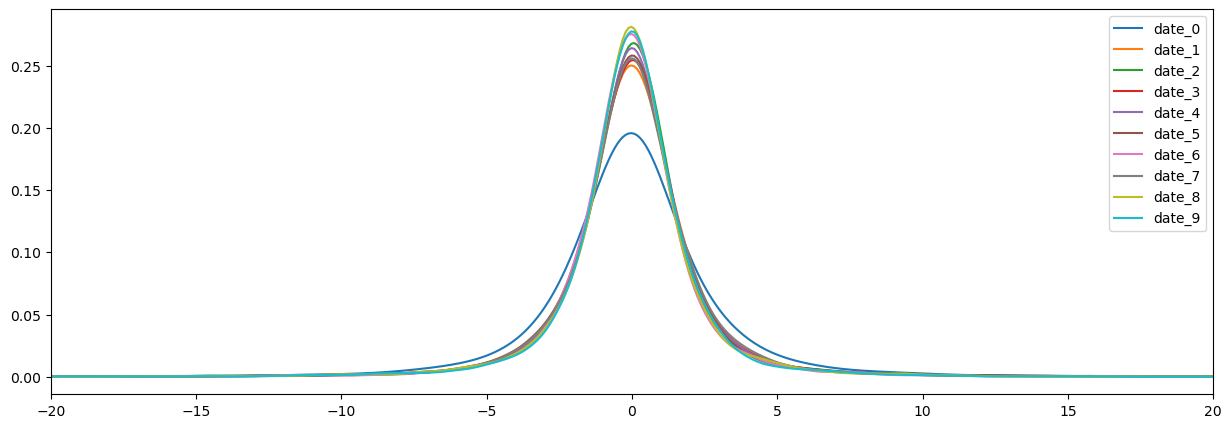

In [295]:
plt.figure(figsize=(15,5))

for date in df_densities.columns:
    plt.plot(df_grids.loc[:, date], df_densities.loc[:, date], label=date)

plt.xlim([-20,20])
plt.legend()
plt.show()

In [228]:
# grid = np.linspace(X_single.min().min(), X_single.max().max(), 5001)

params = {"kernel": "t-student", "df": 2}

kde = KernelDensityEstimation(**params)

grid1, density1 = kde.transform(X_single, h=bw_single.rot())
grid2, density2 = kde.transform(X_single, h=bw_single.adaptive_bandwidth())
bw_single_t = BandwidthSelector(X_single,kernel="t-student", df=params["df"])
grid3, density3 = kde.transform(X_single, h=bw_single_t.adaptive_bandwidth())

/var/folders/t3/pppk4b013151kb4wpjbj3hvh0000gn/T/ipykernel_5468/2650447202.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


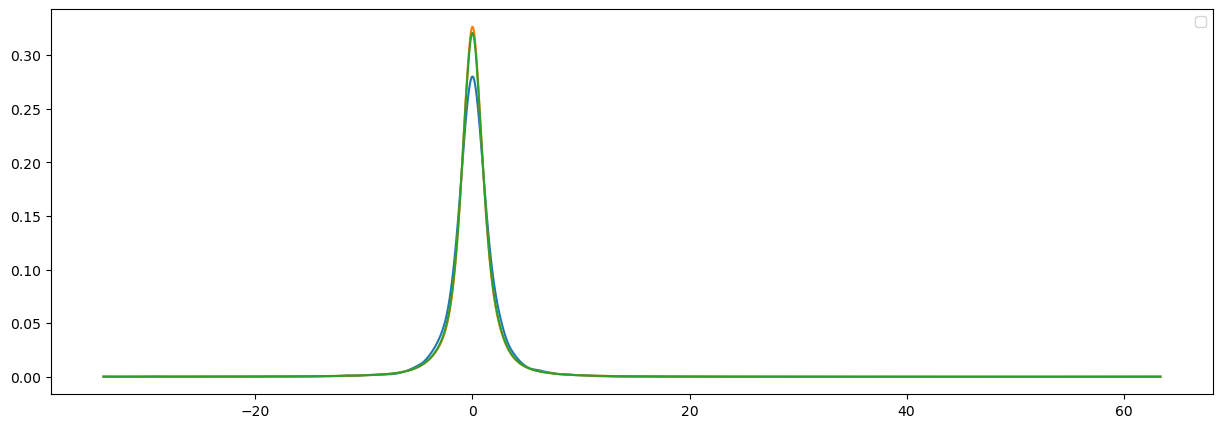

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(grid1, density1)
plt.plot(grid2, density2)
plt.plot(grid3, density3)

plt.show()

# Cross-validation

In [78]:
from sklearn.model_selection import ParameterGrid

# 1. Define the parameter universes for each method
rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "cv": [5]
}

lcv_t_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["t-student"],
    "df": [df for df in range(2,6)],
    "cv": [5]#, "LOO"]
}

kernel_rules = np.unique([v for d in get_rot_bandwidth_ck().values() for v in d.keys()])
adaptive_grid = {
    "method": ["adaptive_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"],
    "h": kernel_rules
}

# 2. Combine grids and build the dictionary
BANDWIDTH_CONFIGS = {}

for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid]:
    for params in ParameterGrid(grid):
        # Create a unique key based on the parameters
        # e.g., "rot_gaussian_robust_True" or "lcv_t-student_df_3"
        key_parts = [params["method"]]
        if "kernel" in params: key_parts.append(params["kernel"])
        if "df" in params: key_parts.append(f"df{params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        # ADD THESE TWO LINES:
        if "alpha" in params: key_parts.append(f"a{params['alpha']}")
        if "h" in params: key_parts.append(f"h{params['h']}") # Distinguish different pilot h values
        
        name = "_".join(key_parts).replace("-", "").replace(".", "") # Remove dots for cleaner keys
        BANDWIDTH_CONFIGS[name] = params

# View a few examples:
print(BANDWIDTH_CONFIGS["rot_gaussian_robust"])
# print(BANDWIDTH_CONFIGS["lcv_tstudent_df3_loo"])

{'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': True}


In [ ]:
# Na validação cruzada, passar chaves como argumentos das funções
BANDWIDTH_CONFIGS

{'rot_gaussian_robust': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': True},
 'rot_gaussian': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': False},
 'rot_epanechnikov_robust': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': True},
 'rot_epanechnikov': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': False},
 'cross_validate_bandwidth_gaussian': {'cv': 5,
  'kernel': 'gaussian',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_epanechnikov': {'cv': 5,
  'kernel': 'epanechnikov',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df2': {'cv': 5,
  'df': 2,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df3': {'cv': 5,
  'df': 3,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_validate_bandwidth_tstudent_df4': {'cv': 5,
  'df': 4,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'cross_val